In [1]:
import numpy as np
from scipy.optimize import linprog
import pandas as pd
import pulp
import networkx as nx
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

## 1. Récupération des données

### a. Chargement des données pour les années 2019 à 2023

In [2]:
# Chargement des données
df_solar_fr_2019 = pd.read_csv("./data_climix/2019/solar_2019.csv")
df_wind_fr_2019 = pd.read_csv("./data_climix/2019/wind_2019.csv")

df_solar_fr_2020 = pd.read_csv("./data_climix/2020/solar_2020.csv")
df_wind_fr_2020 = pd.read_csv("./data_climix/2020/wind_2020.csv")

df_solar_fr_2021 = pd.read_csv("./data_climix/2021/solar_2021.csv")
df_wind_fr_2021 = pd.read_csv("./data_climix/2021/wind_2021.csv")

df_solar_fr_2022 = pd.read_csv("./data_climix/2022/solar_2022.csv")
df_wind_fr_2022 = pd.read_csv("./data_climix/2022/wind_2022.csv")

df_solar_fr_2023 = pd.read_csv("./data_climix/2023/solar_2023.csv")
df_wind_fr_2023 = pd.read_csv("./data_climix/2023/wind_2023.csv")

df_demand = pd.read_csv('demand2050_ADEME.csv', header=None)
df_demand.columns = ["heures", "demande"]

# Calcul consommation annuelle
annual_demand = df_demand['demande'].sum()

# Calcul production potentielle pour 1GW installé
annual_solar_per_gw_fr_2019 = df_solar_fr_2019['facteur_charge'].sum()
annual_wind_per_gw_fr_2019 = df_wind_fr_2019['facteur_charge'].sum()

annual_solar_per_gw_fr_2020 = df_solar_fr_2020['facteur_charge'].sum()
annual_wind_per_gw_fr_2020 = df_wind_fr_2020['facteur_charge'].sum()

annual_solar_per_gw_fr_2021 = df_solar_fr_2021['facteur_charge'].sum()
annual_wind_per_gw_fr_2021 = df_wind_fr_2021['facteur_charge'].sum()

annual_solar_per_gw_fr_2022 = df_solar_fr_2022['facteur_charge'].sum()
annual_wind_per_gw_fr_2022 = df_wind_fr_2022['facteur_charge'].sum()

annual_solar_per_gw_fr_2023 = df_solar_fr_2023['facteur_charge'].sum()
annual_wind_per_gw_fr_2023 = df_wind_fr_2023['facteur_charge'].sum()

# Pour avoir 100% de surproduction et un mix 50-50
target_production = annual_demand * 3.5
wind_capacity_2019 = target_production/(2 * annual_wind_per_gw_fr_2019)
solar_capacity_2019 = target_production/(2 * annual_solar_per_gw_fr_2019)

wind_capacity_2020 = target_production/(2 * annual_wind_per_gw_fr_2020)
solar_capacity_2020 = target_production/(2 * annual_solar_per_gw_fr_2020)

wind_capacity_2021 = target_production/(2 * annual_wind_per_gw_fr_2021)
solar_capacity_2021 = target_production/(2 * annual_solar_per_gw_fr_2021)

wind_capacity_2022 = target_production/(2 * annual_wind_per_gw_fr_2022)
solar_capacity_2022 = target_production/(2 * annual_solar_per_gw_fr_2022)

wind_capacity_2023 = target_production/(2 * annual_wind_per_gw_fr_2023)
solar_capacity_2023 = target_production/(2 * annual_solar_per_gw_fr_2023)

In [3]:
# Configuration des années et types
years = [2019, 2020, 2021, 2022, 2023]
N = len(years)

solar_profiles = []
wind_profiles = []
wind_caps = []
solar_caps = []

df_demand = pd.read_csv('demand2050_ADEME.csv', header=None)
df_demand.columns = ["heures", "demande"]
annual_demand = df_demand['demande'].sum()
target_production = annual_demand * 3.5

for year in years:
    # --- Traitement SOLAIRE ---
    df_s = pd.read_csv(f"./data_climix/{year}/solar_{year}.csv")
    s_vals = df_s['facteur_charge'].values
    
    # Force la taille à 8760
    solar_fc = np.zeros(8760)
    length_s = min(len(s_vals), 8760)
    solar_fc[:length_s] = s_vals[:length_s]
    solar_profiles.append(solar_fc)
    
    # --- Traitement ÉOLIEN ---
    df_wo = pd.read_csv(f"./data_climix/{year}/wind_onshore_{year}.csv")
    wo_vals = df_wo['facteur_charge'].values
    
    # Initialisation du cumul éolien à 8760
    wind_fc = np.zeros(8760)
    length_wo = min(len(wo_vals), 8760)
    wind_fc[:length_wo] = wo_vals[:length_wo]
    
    # Tentative d'ajout de l'offshore
    try:
        df_off = pd.read_csv(f"./data_climix/{year}/wind_offshore_{year}.csv")
        off_vals = df_off['facteur_charge'].values
        length_off = min(len(off_vals), 8760)
        # On ajoute l'offshore au cumul
        wind_fc[:length_off] += off_vals[:length_off]
        print(f"Année {year} : Onshore + Offshore cumulés.")
    except FileNotFoundError:
        print(f"Année {year} : Onshore uniquement.")
        
    wind_profiles.append(wind_fc)
    
    # Calcul des capacités
    ann_solar_gw = solar_fc.sum()
    ann_wind_gw = wind_fc.sum()
    
    wind_caps.append(target_production / (2 * ann_wind_gw))
    solar_caps.append(target_production / (2 * ann_solar_gw))

# Maintenant toutes les listes font exactement 8760, la conversion marchera :
solar_N = np.array(solar_profiles).T
wind_N = np.array(wind_profiles).T

# Pour la demande, on s'assure aussi qu'elle fait 8760
demand_values = df_demand['demande'].values[:8760]
demand_N = np.tile(demand_values * 2.5, (N, 1)).T

wind_cap_N = np.array(wind_caps)
solar_cap_N = np.array(solar_caps)

print(f"\nDonnées prêtes : Matrice Solaire {solar_N.shape}, Matrice Éolienne {wind_N.shape}")

Année 2019 : Onshore + Offshore cumulés.
Année 2020 : Onshore + Offshore cumulés.
Année 2021 : Onshore + Offshore cumulés.
Année 2022 : Onshore + Offshore cumulés.
Année 2023 : Onshore + Offshore cumulés.

Données prêtes : Matrice Solaire (8760, 5), Matrice Éolienne (8760, 5)


### b. Chargement des valeurs d'échange maximales

In [4]:
T = len(df_demand)
N = 5

qmax11pays = np.array([[0 ,50,20,30,40,70,20,30,50,40,70],
                       [50,0 ,80,40,30,20,50,0 ,70,60,30],
                       [20,80,0 ,60,50,60,40,30,70,50,20],
                       [30,40,60,0 ,40,60,0 ,40,60,0 ,40],
                       [40,30,50,40,0 ,40,30,70,60,80,70],
                       [70,20,60,60,40,0 ,20,30,20,60,60],
                       [20,50,40,0 ,30,20,0 ,40,50,60,40],
                       [30,0 ,30,40,70,30,40,0 ,30,70,50],
                       [50,70,70,60,60,20,50,30,0 ,30,60],
                       [40,60,50,0 ,80,60,60,70,30,0 ,30],
                       [70,30,20,40,70,60,40,50,60,30,0 ]])

qmax = qmax11pays[:N,:N]

Ces données sont celles de la France sur 5 années différentes, il faudra prendre le temps de les changer pour avoir des résultats interressants.

--> voir ce site pour données réelles : https://transparency.entsoe.eu/

## 2. Définition du problème

In [5]:
def extract_results(prob, T, N,
                    phs_in, phs_out, phs_level,
                    ptg_in, ptg_out, ptg_level,
                    deficit, surplus, q, prod):

    phs_in_array    = np.zeros((T, N))
    phs_out_array   = np.zeros((T, N))
    phs_level_array = np.zeros((T, N))

    ptg_in_array    = np.zeros((T, N))
    ptg_out_array   = np.zeros((T, N))
    ptg_level_array = np.zeros((T, N))

    deficit_array = np.zeros((T, N))
    surplus_array = np.zeros((T,N))
    
    q_array = np.zeros((T, N, N))
    
    for t in range(T):
        for i in range(N):
            phs_in_array[t, i]    = pulp.value(phs_in[t][i])
            phs_out_array[t, i]   = pulp.value(phs_out[t][i])
            phs_level_array[t, i] = pulp.value(phs_level[t][i])

            ptg_in_array[t, i]    = pulp.value(ptg_in[t][i])
            ptg_out_array[t, i]   = pulp.value(ptg_out[t][i])
            ptg_level_array[t, i] = pulp.value(ptg_level[t][i])

            deficit_array[t, i] = pulp.value(deficit[t][i])
            surplus_array[t, i] = pulp.value(surplus[t][i])

            for j in range(N):
                if i != j:
                    q_array[t, i, j] = pulp.value(q[t][i][j])

    return {        
        
        'status': pulp.LpStatus[prob.status],
        
        'prod' : prod,
        
        'phs_in': phs_in_array,
        'phs_out': phs_out_array,
        'phs_level': phs_level_array,

        'ptg_in': ptg_in_array,
        'ptg_out': ptg_out_array,
        'ptg_level': ptg_level_array,

        'deficit': deficit_array,
        'surplus': surplus_array,

        'Echanges': q_array
    }

In [ ]:
def optimize(
    wind_profile, solar_profile, demand,
    wind_cap, solar_cap, qmax_matrix,
    phs_capacity=180, phs_power=9.3, phs_eff=0.75,
    ptg_capacity=125000, ptg_power_in=7.66, ptg_power_out=32.93,
    ptg_eff=0.4, penalisation=1e10, flux_eff=0.9
):
    
    """
    Optimise la stratégie de stockage sur l'année avec contrainte cyclique pour n pays
    
    Parameters:
    -----------
    solar_profile, wind_profile: séries temporelles des facteurs de charge
    demand: série temporelle de la demande
    wind_cap, solar_cap: capacités installées en GW
    phs_capacity: capacité de stockage PHS en GWh
    phs_power: puissance max PHS en GW
    phs_efficiency: rendement PHS (aller-retour)
    ptg_capacity: capacité de stockage P2G en GWh
    ptg_power_in: puissance max électrolyse en GW  
    ptg_power_out: puissance max reconversion en GW
    ptg_efficiency: rendement P2G (aller-retour)
    qmax_matrix : np.array (N, N), symétrique, diag = 0
    flux_eff : flux moins les pertes lors du transport

    """

    T, N = demand.shape

    # =====================
    # Production
    # =====================
    prod = np.zeros((T, N))
    for t in range(T):
        prod[t, :] = (
            wind_cap * wind_profile[t, :]
            + solar_cap * solar_profile[t, :]
        )

    # =====================
    # Problème
    # =====================
    prob = pulp.LpProblem("Energy_System", pulp.LpMinimize)

    # =====================
    # Variables
    # =====================

    phs_in    = pulp.LpVariable.dicts("phs_in",    (range(T), range(N)), lowBound=0)
    phs_out   = pulp.LpVariable.dicts("phs_out",   (range(T), range(N)), lowBound=0)
    phs_level = pulp.LpVariable.dicts("phs_level", (range(T), range(N)), lowBound=0)

    ptg_in    = pulp.LpVariable.dicts("ptg_in",    (range(T), range(N)), lowBound=0)
    ptg_out   = pulp.LpVariable.dicts("ptg_out",   (range(T), range(N)), lowBound=0)
    ptg_level = pulp.LpVariable.dicts("ptg_level", (range(T), range(N)), lowBound=0)

    deficit = pulp.LpVariable.dicts("deficit", (range(T), range(N)), lowBound=0)
    surplus = pulp.LpVariable.dicts("surplus", (range(T), range(N)), lowBound=0)

    q = pulp.LpVariable.dicts(
        "q", (range(T), range(N), range(N)), lowBound=0
    )

    # =====================
    # Fonction objectif
    # =====================

    prob += (
        pulp.lpSum(-ptg_level[T-1][i] for i in range(N))
        + penalisation * pulp.lpSum(deficit[t][i] for t in range(T) for i in range(N)) + 0.1*pulp.lpSum(q[t][i][j] for t in range(T) for i in range(N) for j in range(N) if i != j
    ))

    # =====================
    # Contraintes
    # =====================

    # Conditions initiales
    for i in range(N):
        prob += phs_level[0][i] == phs_capacity / 2
        prob += ptg_level[0][i] == ptg_capacity

    for t in range(T):
        for i in range(N):

            inflow  = pulp.lpSum(q[t][j][i] for j in range(N) if j != i)
            outflow = pulp.lpSum(q[t][i][j] for j in range(N) if j != i)

            # Bilan énergie
            prob += (
                prod[t, i] 
                + phs_out[t][i] * phs_eff 
                + ptg_out[t][i] * ptg_eff 
                + inflow * flux_eff 
                + deficit[t][i]
                == 
                demand[t, i] 
                + phs_in[t][i] 
                + ptg_in[t][i] 
                + outflow 
                + surplus[t][i]
            )

            # Limites PHS
            prob += phs_in[t][i]  <= phs_power
            prob += phs_out[t][i] <= phs_power
            prob += phs_level[t][i] <= phs_capacity

            # Limites PtG
            prob += ptg_in[t][i]  <= ptg_power_in
            prob += ptg_out[t][i] <= ptg_power_out
            prob += ptg_level[t][i] <= ptg_capacity

            # Évolution des stocks
            if t > 0:
                prob += (
                    phs_level[t][i]
                    == phs_level[t-1][i]
                    + phs_in[t][i] * phs_eff
                    - phs_out[t][i]
                )

                prob += (
                    ptg_level[t][i]
                    == ptg_level[t-1][i]
                    + ptg_in[t][i] * ptg_eff
                    - ptg_out[t][i]
                )

            # Contraintes échanges
            for j in range(N):
                if i != j:
                    prob += q[t][i][j] <= qmax_matrix[i, j]
                else:
                    prob += q[t][i][j] == 0

    # =====================
    # Résolution
    # =====================
    prob.solve(pulp.PULP_CBC_CMD(msg=False))
    
    return extract_results(
    prob, T, N,
    phs_in, phs_out, phs_level,
    ptg_in, ptg_out, ptg_level,
    deficit, surplus, q, prod)


## 3. Execution de l'optimisation

In [ ]:
result = optimize(
    wind_profile=wind_N,
    solar_profile=solar_N,
    demand=demand_N,
    wind_cap=wind_cap_N,
    solar_cap=solar_cap_N,
    qmax_matrix=qmax,
    phs_capacity=30*180, #modifié en faisant 30*
    phs_power=5*9.3,     #modifié en faisant 5*
    phs_eff=0.75,  
    ptg_capacity=125000,
    ptg_power_in=100*7.66,   #modifié en faisant 100*
    ptg_power_out=2*32.93,   #modifié en faisant 2*
    ptg_eff=0.4
)

print(f"Statut de l'optimisation : {result['status']}")

## 4. Interprétation graphique

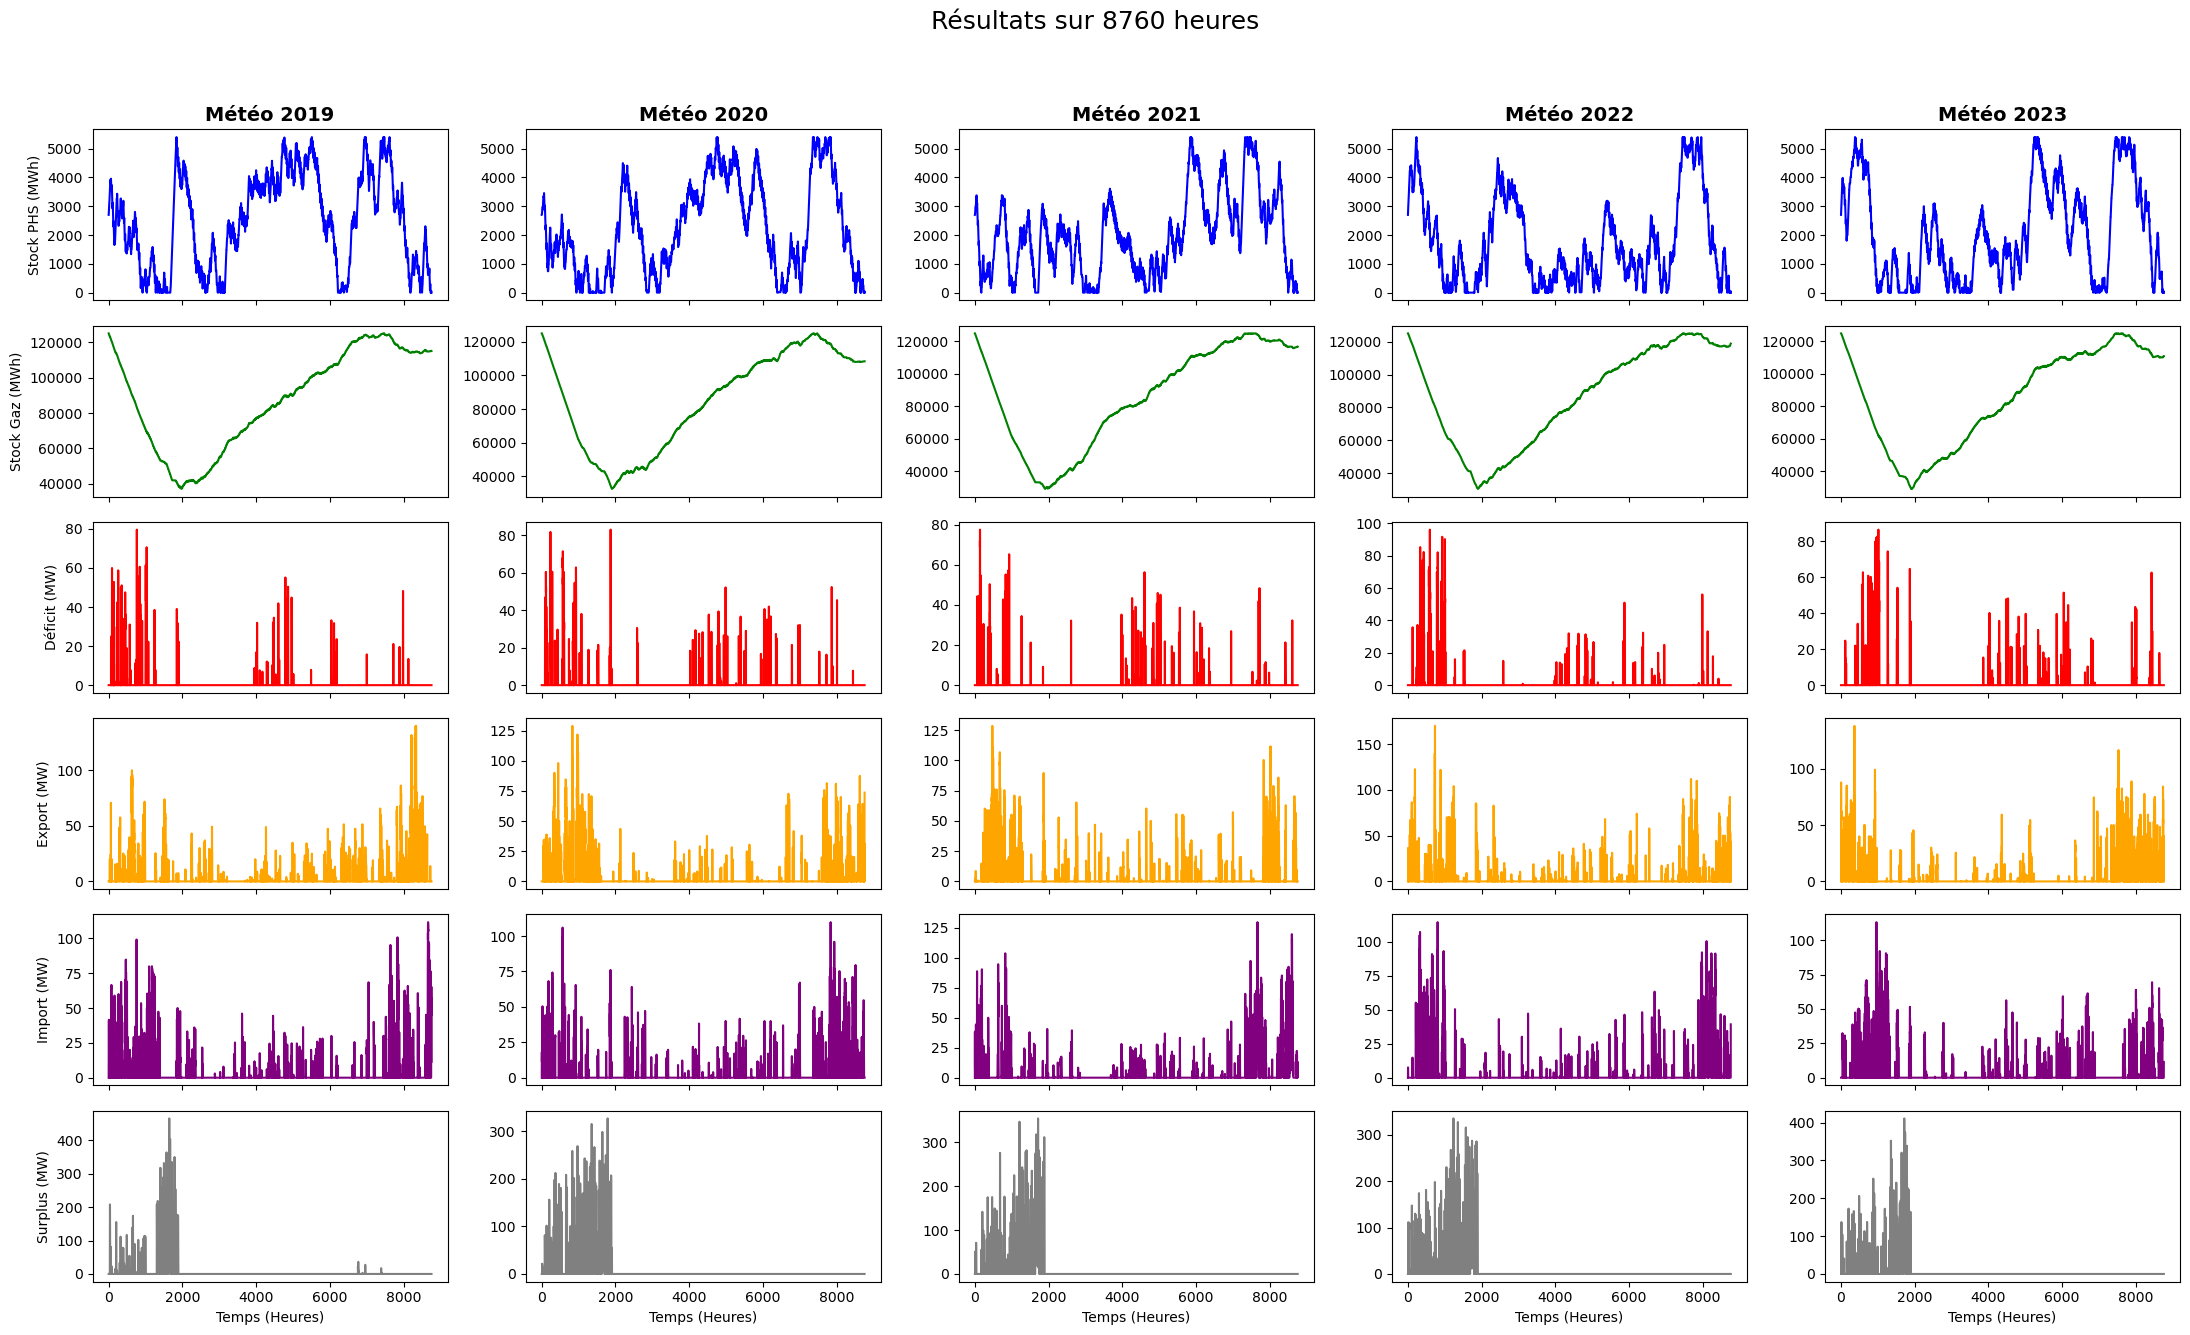

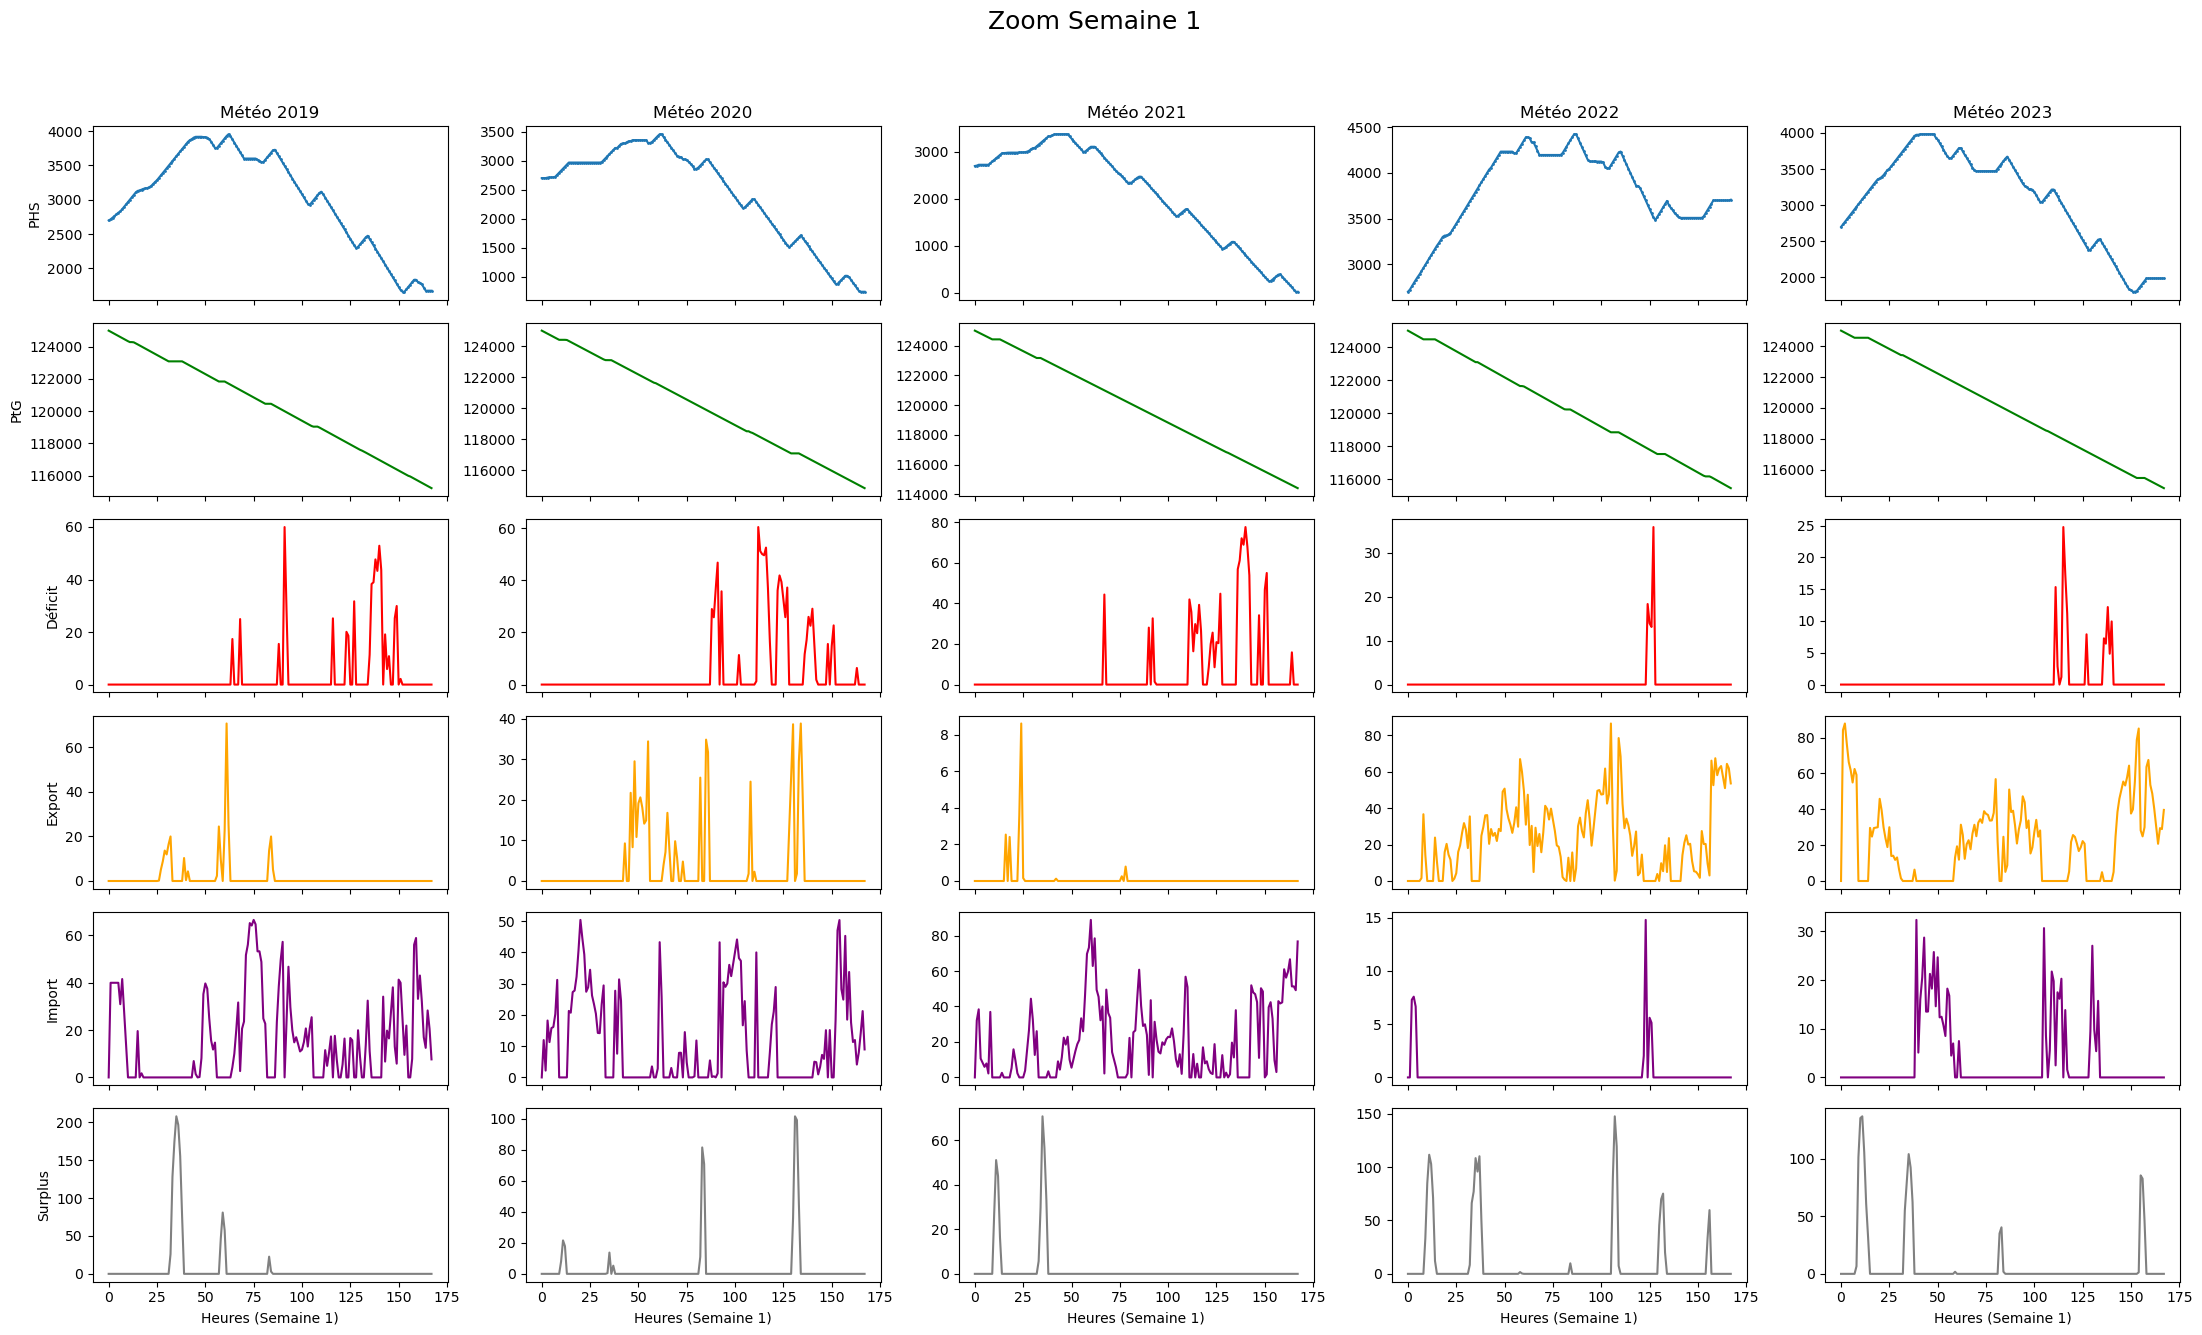

In [12]:
# On définit les labels pour les titres
year_labels = [str(y) for y in years] 
N = result['phs_level'].shape[1]

# --- Flux ---
q = result["Echanges"]  # (T, N, N)
sent = np.sum(q, axis=2)
received = np.sum(q, axis=1)

# =====================================================
# GRAPHE GLOBAL (8760 heures)
# =====================================================
T_plot = 8760
fig, axes = plt.subplots(6, N, figsize=(22, 14), sharex=True)

for i in range(N):
    # Titre avec l'année au lieu de "Pays X"
    axes[0, i].set_title(f"Météo {year_labels[i]}", fontsize=14, fontweight='bold')

    # PHS Level
    axes[0, i].plot(result['phs_level'][:T_plot, i], color='blue')
    if i == 0: axes[0, i].set_ylabel("Stock PHS (MWh)")

    # PtG Level
    axes[1, i].plot(result['ptg_level'][:T_plot, i], color='green')
    if i == 0: axes[1, i].set_ylabel("Stock Gaz (MWh)")

    # Déficit (énergie non servie)
    axes[2, i].plot(result['deficit'][:T_plot, i], color='red')
    if i == 0: axes[2, i].set_ylabel("Déficit (MW)")

    # Flux sortants
    axes[3, i].plot(sent[:T_plot, i], color='orange')
    if i == 0: axes[3, i].set_ylabel("Export (MW)")

    # Flux entrants
    axes[4, i].plot(received[:T_plot, i], color='purple')
    if i == 0: axes[4, i].set_ylabel("Import (MW)")

    # Surplus (perdu ou non utilisé)
    axes[5, i].plot(result['surplus'][:T_plot, i], color='gray')
    if i == 0: axes[5, i].set_ylabel("Surplus (MW)")
    axes[5, i].set_xlabel("Temps (Heures)")

plt.suptitle(f"Résultats sur 8760 heures", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# =====================================================
# ZOOM SEMAINE
# =====================================================
semaine = 1
T0 = 168 * (semaine - 1)
T1 = T0 + 168

fig, axes = plt.subplots(6, N, figsize=(22, 14), sharex=True)

for i in range(N):
    axes[0, i].set_title(f"Météo {year_labels[i]}", fontsize=12)

    axes[0, i].plot(result['phs_level'][T0:T1, i], marker='.', markersize=2)
    if i == 0: axes[0, i].set_ylabel("PHS")

    axes[1, i].plot(result['ptg_level'][T0:T1, i], color='green')
    if i == 0: axes[1, i].set_ylabel("PtG")

    axes[2, i].plot(result['deficit'][T0:T1, i], color='red')
    if i == 0: axes[2, i].set_ylabel("Déficit")

    axes[3, i].plot(sent[T0:T1, i], color='orange')
    if i == 0: axes[3, i].set_ylabel("Export")

    axes[4, i].plot(received[T0:T1, i], color='purple')
    if i == 0: axes[4, i].set_ylabel("Import")
    
    axes[5, i].plot(result['surplus'][T0:T1, i], color='gray')
    if i == 0: axes[5, i].set_ylabel("Surplus")
    axes[5, i].set_xlabel(f"Heures (Semaine {semaine})")

plt.suptitle(f"Zoom Semaine {semaine}", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

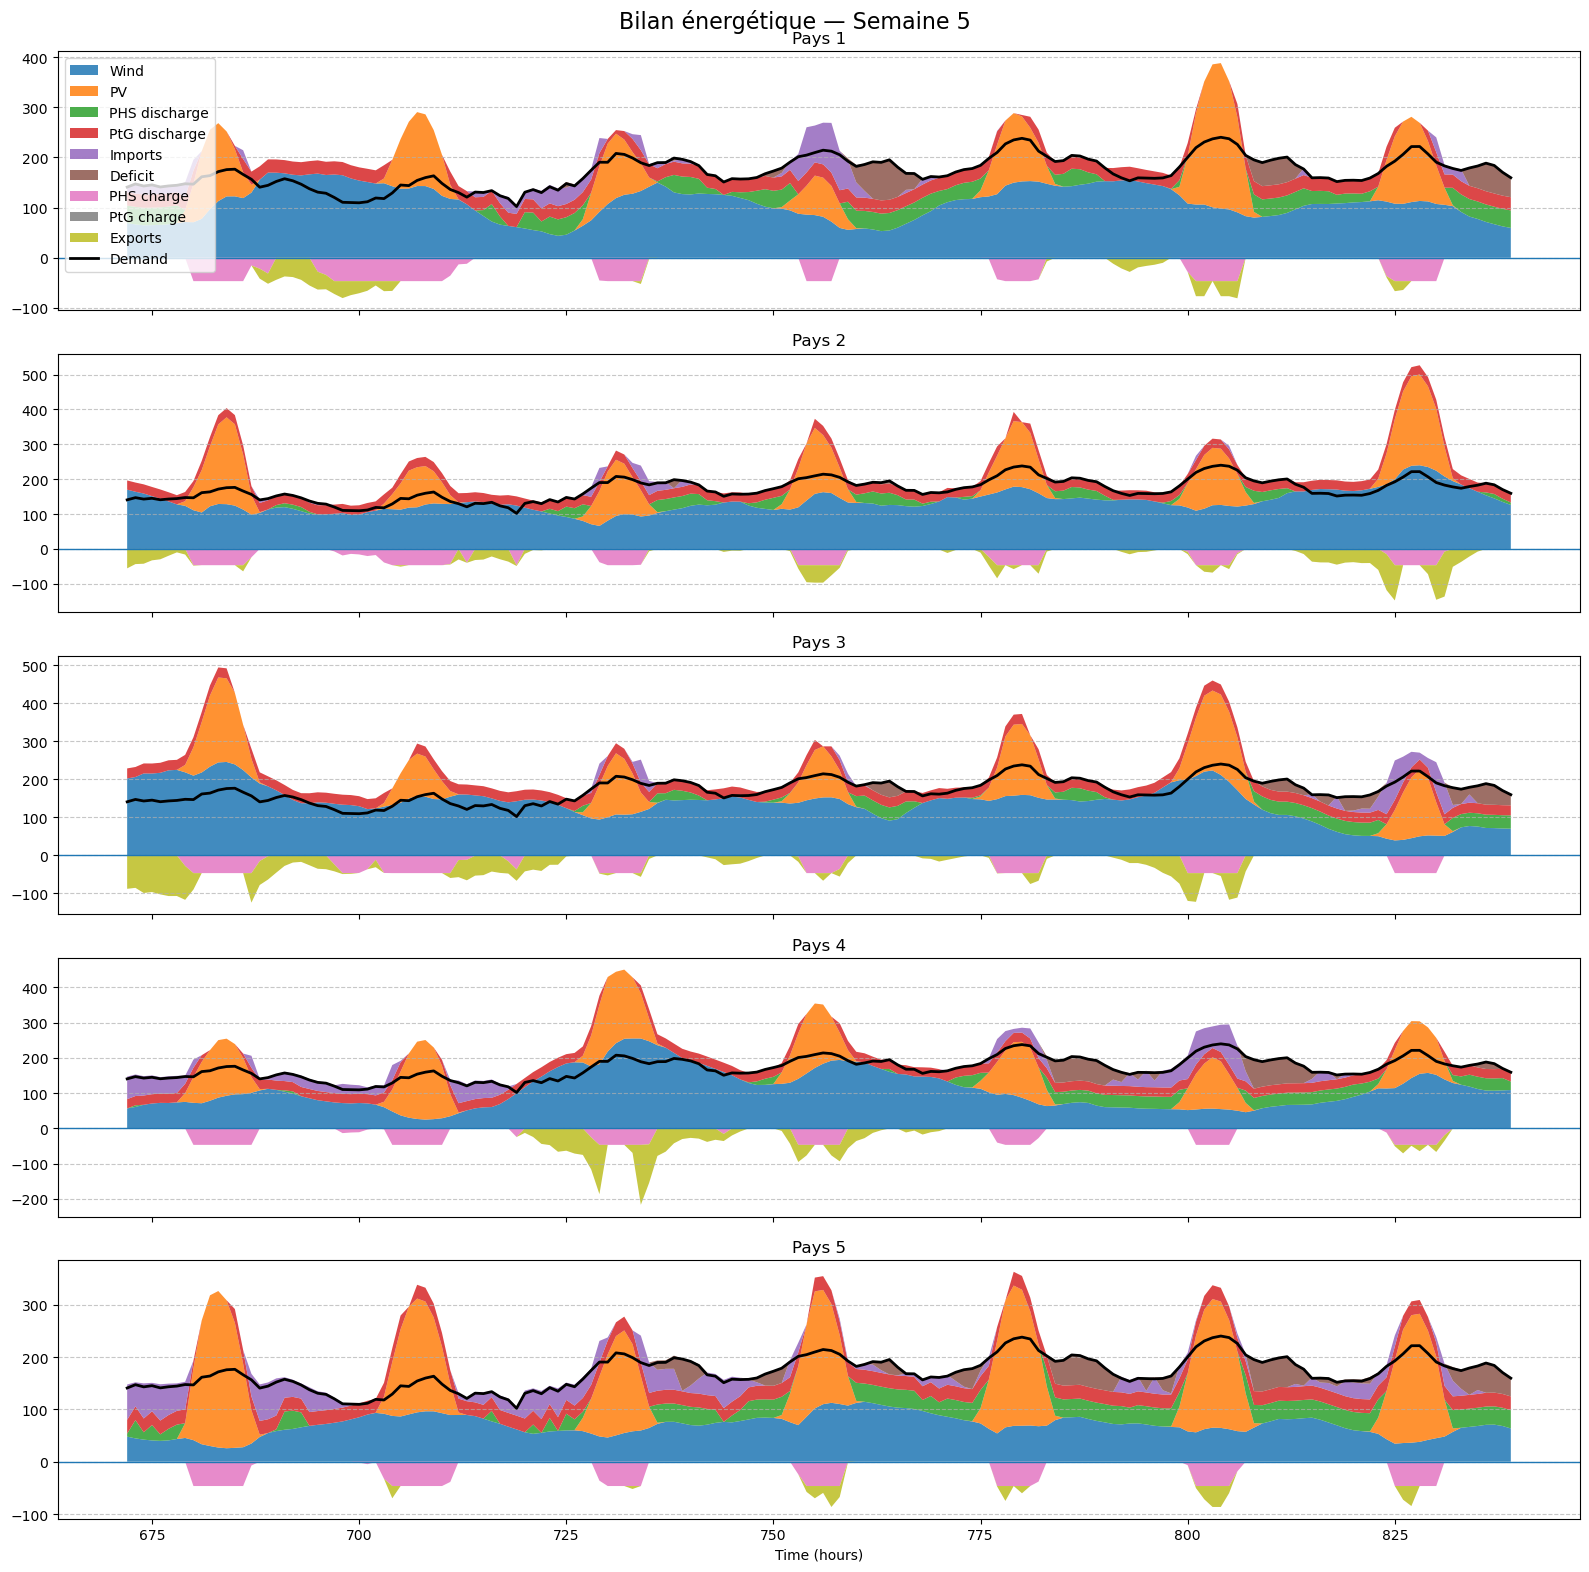

In [9]:
# ===============================
# Flux échanges
# ===============================

ptg_eff=0.4
phs_eff = 0.75
time_axis = np.arange(T0, T1)

q = result["Echanges"]

imports = np.sum(q, axis=1)
exports = np.sum(q, axis=2)

fig, axes = plt.subplots(N, 1, figsize=(16, 16), sharex=True)

for i in range(N):

    # --- Production ---
    wind_i = (wind_N*wind_cap_N)[T0:T1, i]
    solar_i = (solar_N*solar_cap_N)[T0:T1, i]

    # --- Déstockage ---
    phs_dis = phs_eff * result['phs_out'][T0:T1, i]
    ptg_dis = ptg_eff * result['ptg_out'][T0:T1, i]

    # --- Stockage (négatif) ---
    phs_ch = -result['phs_in'][T0:T1, i]
    ptg_ch = -result['ptg_in'][T0:T1, i]

    # --- Echanges ---
    import_i = imports[T0:T1, i]
    export_i = -exports[T0:T1, i]   # NEGATIF

    deficit_i = result['deficit'][T0:T1, i]
    demand_i = demand_N[T0:T1, i]

    # ===== STACK POSITIF =====
    stack_pos = [
        wind_i,
        solar_i,
        phs_dis,
        ptg_dis,
        import_i,
        deficit_i
    ]

    labels_pos = [
        'Wind',
        'PV',
        'PHS discharge',
        'PtG discharge',
        'Imports',
        'Deficit'
    ]

    axes[i].stackplot(time_axis, stack_pos, alpha=0.85)

    # ===== STACK NEGATIF =====
    stack_neg = [
        phs_ch,
        ptg_ch,
        export_i
    ]

    axes[i].stackplot(time_axis, stack_neg, alpha=0.85)

    # --- Demande ---
    axes[i].plot(time_axis,
                 demand_i,
                 color='black',
                 linewidth=2,
                 label='Demand')

    axes[i].axhline(0, linewidth=1)

    axes[i].set_title(f"Pays {i+1}")
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    if i == 0:
        axes[i].legend(labels_pos + ['PHS charge','PtG charge','Exports','Demand'],
                       loc='upper left', fontsize=10)

axes[-1].set_xlabel("Time (hours)")
plt.suptitle(f"Bilan énergétique — Semaine {semaine}", fontsize=16)
plt.tight_layout()
plt.show()